In [1]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
from tqdm import tqdm #
from numba import jit, prange

In [2]:
image_path = "../Sourse_Images/Odom_images/"
image_number = 4
image_base_name = "Point"
image_type = ".jpg"
#image_list = ["Point1.jpg"]

In [6]:
image_name_list = []
for i in range(image_number):
    image_name_list.append(image_base_name + f"{i+1}")
sorce_image_path_list = []
for i in range(image_number):
    sorce_image_path_list.append(image_path + image_name_list[i] + image_type)

In [7]:
sorce_image_path_list

['../Sourse_Images/Odom_images/Point1.jpg',
 '../Sourse_Images/Odom_images/Point2.jpg',
 '../Sourse_Images/Odom_images/Point3.jpg',
 '../Sourse_Images/Odom_images/Point4.jpg']

In [8]:
sorce_image_list = []
for i in range(len(sorce_image_path_list)):
    sorce_image_list.append(mpimg.imread(sorce_image_path_list[i]))

In [9]:
def visualize_images(image_list, H = 2, W = 2, label_list = []):
    if H*W != len(image_list):
        print("Несоответствие сетки и числа изображений")
        print(f"Элементов в сетке {H*W}, всего элементов {len(image_list)}")
        return 0
    if len(label_list) == len(image_list):
        lables = True
    else: lables = False
    fig, ax = plt.subplots(H, W, figsize=(15,15))
    if H == 1:
        for i in range(W):
            ax[i].imshow(image_list[i])  #, cmap='gray'
            ax[i].axis('off')
            if(lables):
                ax[i].set_title(label_list[i])  
    else:
        for i in range(H*W):
            h = i // W  
            w = i % W
            ax[h, w].imshow(image_list[i])
            ax[h, w].axis('off')
            if(lables):
                ax[h, w].set_title(label_list[i])  

    plt.tight_layout()
    plt.show()

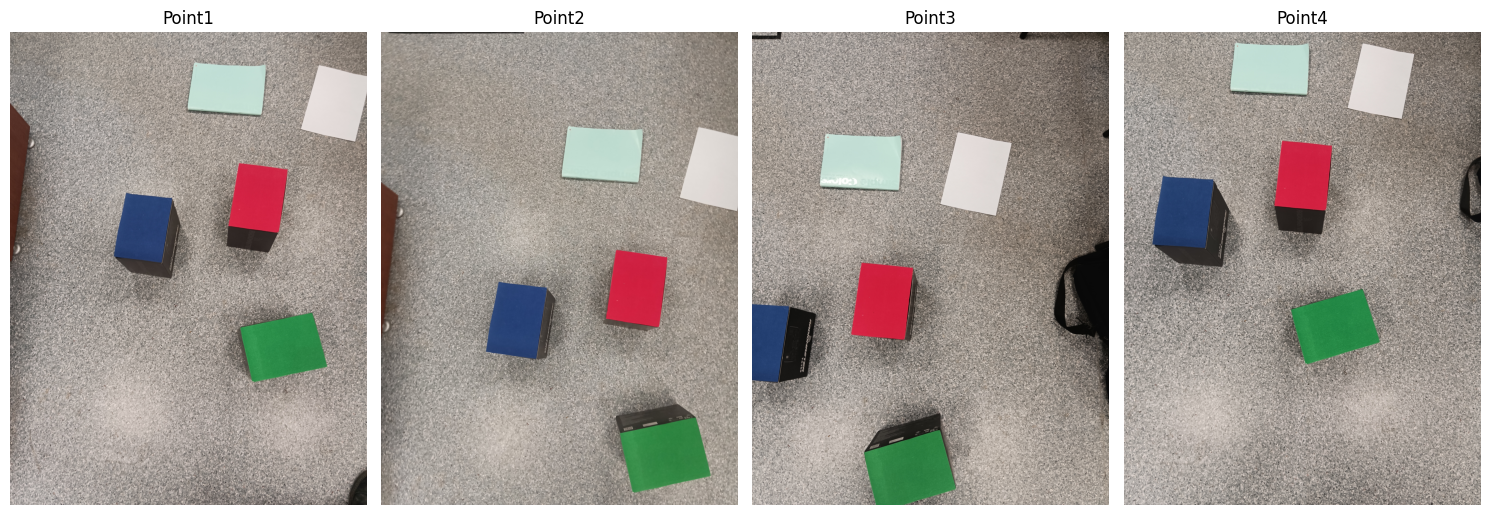

In [10]:
visualize_images(sorce_image_list, H = 1, W = 4, label_list = image_name_list)

In [11]:
def find_local_feature():
    pass

### SIFT Scale-Invariant Feature Transform

Детектор DoG

	• Определение положения и масштаба особенности

Ориентация

	• Определение доминантной ориентации по градиентам

Дескриптор

	• Использование статистик по направлению градиентам

Устойчив к изменениям освещенности и небольшим сдвигам

In [51]:
# Создание объекта SIFT (современный способ)
#sift = cv2.SIFT_create()
sift = cv2.SIFT_create(
    nfeatures=30,           # Оставить только 500 лучших ключевых точек
    nOctaveLayers=3,          # Количество слоёв в каждой октаве (стандарт - 3)
    contrastThreshold=0.04,    # Порог контрастности для фильтрации слабых точек
    edgeThreshold=10,          # Порог для фильтрации краёв (чем выше, тем больше точек остаётся)
    sigma=1.6                  # Параметр размытия для нулевой октавы
)

In [ ]:
img = sorce_image_list[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [54]:
# Обнаружение ключевых точек (только ключевые точки)
keypoints = sift.detect(gray, None)

In [55]:
type(keypoints)

tuple

In [56]:
len(keypoints)

30

In [42]:
#keypoints, descriptors = sift.detectAndCompute(gray, None)

In [57]:
output = np.zeros_like(img)
# Отрисовка ключевых точек на изображении
# Флаг DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS отображает размер и ориентацию
img_with_keypoints = cv2.drawKeypoints(gray, 
                                       keypoints, 
                                       output, 
                                       flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

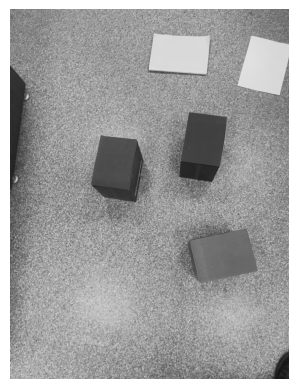

In [58]:
plt.imshow(img_with_keypoints)
plt.axis('off')  # скрыть оси
plt.show()

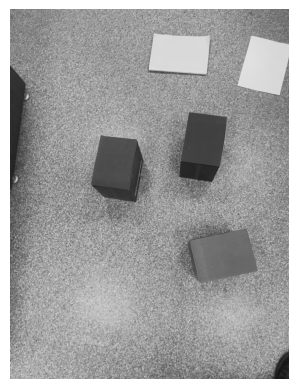

In [59]:
plt.imshow(output)
plt.axis('off')  # скрыть оси
plt.show()

In [60]:
# SIFT детектор
#sift = cv2.SIFT_create()
#keypoints, descriptors = sift.detectAndCompute(gray, None)

# ОТОБРАЖЕНИЕ С РАЗМЕРАМИ И ОРИЕНТАЦИЕЙ
img_rich = img.copy()
cv2.drawKeypoints(img_rich, 
                  keypoints, 
                  img_rich, 
                  color=(0, 255, 0),  # Цвет точек
                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Добавим информационную надпись
#cv2.putText(img_rich, f'Найдено точек: {len(keypoints)}', (10, 30), 
#            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
window_name = 'SIFT с размерами и ориентацией'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
#cv2.imshow('SIFT с размерами и ориентацией', img_rich)
cv2.imshow(window_name, img_rich)
cv2.resizeWindow(window_name, 600, 400)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [46]:
# Загрузка изображения
img = sorce_image_list[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Создание SIFT объекта
sift = cv2.SIFT_create()

# Одновременное обнаружение ключевых точек и вычисление дескрипторов (РЕКОМЕНДУЕТСЯ)
keypoints, descriptors = sift.detectAndCompute(gray, None)

print(f"Найдено ключевых точек: {len(keypoints)}")
print(f"Форма дескрипторов: {descriptors.shape}")  # (N, 128) - каждая точка имеет 128-мерный вектор

# Если у вас уже есть ключевые точки, можно вычислить только дескрипторы:
# keypoints = sift.detect(gray, None)
# keypoints, descriptors = sift.compute(gray, keypoints)

Найдено ключевых точек: 159145
Форма дескрипторов: (159145, 128)


In [34]:
# Создание SIFT с пользовательскими параметрами
sift = cv2.SIFT_create(
    nfeatures=500,           # Оставить только 500 лучших ключевых точек
    nOctaveLayers=3,          # Количество слоёв в каждой октаве (стандарт - 3)
    contrastThreshold=0.04,    # Порог контрастности для фильтрации слабых точек
    edgeThreshold=10,          # Порог для фильтрации краёв (чем выше, тем больше точек остаётся)
    sigma=1.6                  # Параметр размытия для нулевой октавы
)

keypoints, descriptors = sift.detectAndCompute(gray, None)

nfeatures: Если вам нужно ограниченное количество самых сильных признаков.

contrastThreshold: Увеличение значения уменьшает количество точек, делая их более "качественными" .

edgeThreshold: Влияет на то, насколько агрессивно алгоритм отсеивает точки, лежащие на границах объектов.

In [35]:
import cv2
import numpy as np

# Загрузка двух изображений
img1 = sorce_image_list[0]
img2 = sorce_image_list[1]
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Инициализация SIFT
#sift = cv2.SIFT_create()

# Нахождение ключевых точек и дескрипторов
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Настройка FLANN-сопоставителя (алгоритм приближённого поиска соседей)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Применение соотношения Лоу (Lowe's ratio test) для отбора хороших совпадений
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print(f"Найдено хороших совпадений: {len(good_matches)}")

# Извлечение координат совпавших точек (понадобятся для оценки движения)
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# Дальше можно использовать src_pts и dst_pts для findEssentialMat/recoverPose

Найдено хороших совпадений: 23


Настройка: экспериментируйте с параметрами (contrastThreshold, edgeThreshold), чтобы сбалансировать количество и качество признаков для вашей задачи
Для задач визуальной одометрии, о которой мы говорили ранее, связка SIFT (detectAndCompute) + FLANN-сопоставитель + фильтрация по соотношению Лоу является классическим и надёжным подходом для нахождения соответствий между кадрами

In [ ]:
import numpy as np
import cv2

# Допустим, у нас уже есть:
# kp1, kp2 - ключевые точки (список объектов cv2.KeyPoint)
# matches - список объектов cv2.DMatch

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Теперь src_pts и dst_pts готовы к передаче в findEssentialMat
E, mask = cv2.findEssentialMat(src_pts, dst_pts, focal=..., pp=...)

# Или в recoverPose
_, R, t, mask = cv2.recoverPose(E, src_pts, dst_pts, focal=..., pp=...)